In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from binomial_model import option_price, option_price_no_volatility
from visualization import plot_binomial_trees
from black_scholes_merton import BSM_pricing

In [ ]:
price, stocks, options, timeline = option_price(option_type="call", exercise_style="American", s=100, k=100,
                                                vol=0.2, T=1, N=4, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [ ]:
#figure 13.7
price, stocks, options, timeline = option_price_no_volatility(option_type='put',exercise_style='European', s=50, k=52, 
                                                              up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [ ]:
#figure 13.8
price, stocks, options, timeline = option_price_no_volatility(option_type='put',exercise_style='American', s=50, k=52, 
                                                                     up=20, down=20, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [ ]:
# practice 13.7
price, stocks, options, timeline =  option_price_no_volatility(option_type='call',exercise_style='European',s=50, k=51, 
                                                                      up=6, down=5, T=0.5, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [ ]:

option_value, stocks, options, timeline = option_price(option_type='put',exercise_style='American', s=50, k=52, 
                                                       vol=0.3, T=2, N=2, r=0.05, return_tree=True)

plot_binomial_trees(stocks, options, timeline)

In [ ]:
# Example 15.6
print(BSM_pricing(option_type='call', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))
print(BSM_pricing(option_type='put', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))

In [ ]:
prices = []
time_steps = np.arange(2,101)
BSM_price = BSM_pricing(option_type='put', exercise_style='European', s=50, k=50, T=1, r=0.1, q=0, sigma=0.4)


for N in time_steps:
    price = option_price(option_type="put", exercise_style="European", s=50, k=50,
                                                vol=0.4, T=1, N=N, r=0.1, return_tree=False)
    prices.append(price)

plt.plot(time_steps, prices, marker='o', linestyle='-', ms=5)
plt.axhline(y=BSM_price, color='r', linestyle='--', label='BSM price')
plt.ylabel('option prices')
plt.xlabel('time steps')
plt.title('Convergence of Binomial Tree Price to Black-Scholes-Merton Price')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from greeks import delta
stocks = np.linspace(1,100,100)
deltas_call = np.zeros(100)
deltas_put = np.zeros(100)
for i, s in enumerate(stocks):
    deltas_call[i] = delta(option_type='call', s=s, k=50, r=0, sigma=0.25, T=2)
    deltas_put[i] = delta(option_type='put', s=s, k=50, r=0, sigma=0.25, T=2)

plt.plot(stocks, deltas_call, label='call')
plt.plot(stocks, deltas_put, label='put')
plt.ylabel('delta')
plt.xlabel('stock price')
plt.title('Variation of delta with stock price for a call and put option \n on a non-dividend-paying stock')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from greeks import delta

maturities = np.linspace(0.1,20,100)

for k, moneyness, linestyle in zip(
    [40,50,60],
    ['In the money','At the money','Out of the money'], 
    ['-','--','-.']
):
    deltas_call = np.zeros(100)
    
    for i, t in enumerate(maturities):
        deltas_call[i] = delta(option_type='call', s=50, k=k, r=0, sigma=0.25, T=t)

    plt.plot(maturities, deltas_call, linestyle=linestyle, label=f'{moneyness} (K={k})')
plt.ylabel('delta')
plt.xlabel('time to maturity (years)')
plt.title('Variation of delta with time to maturity for a call option \n s=50, r=0, sigma=0.25')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

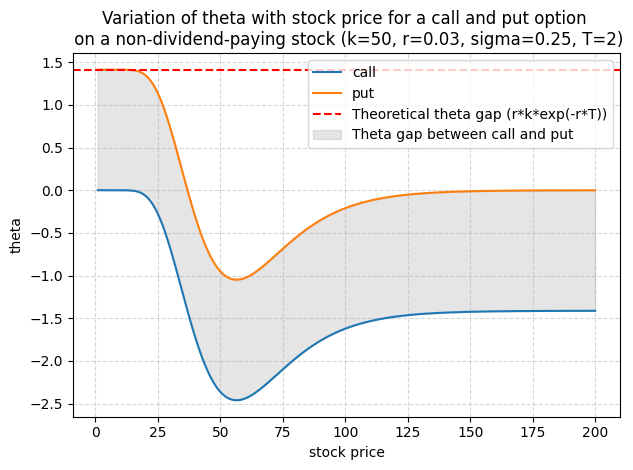

In [19]:
from greeks import theta
stocks = np.linspace(1,200,200)
k, r, sigma, T = 50, 0.03, 0.25, 2
theta_vec = np.vectorize(theta)

thetas_call = theta_vec(option_type='call', s=stocks, k=k, r=r, sigma=sigma, T=T)
thetas_put = theta_vec(option_type='put', s=stocks, k=k, r=r, sigma=sigma, T=T)

theta_gap = r*k*np.exp(-r*T)

plt.plot(stocks, thetas_call, label='call')
plt.plot(stocks, thetas_put, label='put')
plt.axhline(y=theta_gap, color='r', linestyle='--', label='Theoretical theta gap (r*k*exp(-r*T))')
plt.fill_between(stocks, thetas_call, thetas_put, color='grey', alpha=0.2, label='Theta gap between call and put')
plt.ylabel('theta')
plt.xlabel('stock price')
plt.title('Variation of theta with stock price for a call and put option \n on a non-dividend-paying stock (k=50, r=0.03, sigma=0.25, T=2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

array([-1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126468,
       -1.4126468, -1.4126468, -1.4126468, -1.4126468, -1.4126